In [12]:
import os, glob, math
import numpy as np

import cv2
from PIL import Image

import torch
import torch.nn as nn 
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T


import matplotlib.pyplot as plt

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True  # enable cudnn autotuner for convs
# (Optional) slightly faster matmul kernels on Ampere+:
try:
    torch.set_float32_matmul_precision('medium')
except Exception:
    pass

print(device)

cuda


In [14]:
os.path.exists('./data/caltech_face_nonface/non_faces')

False

torch.Size([126, 126])


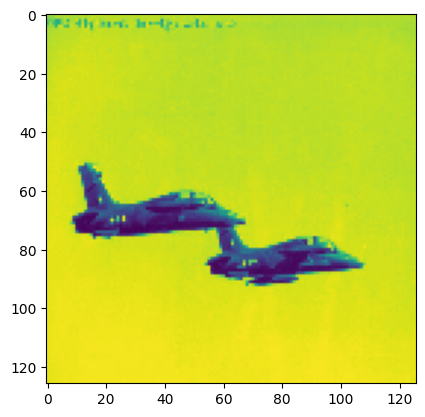

In [15]:

test_img = cv2.imread('../data/caltech_face_nonface/non_faces/0001.png', cv2.IMREAD_GRAYSCALE)
test_img = cv2.resize(test_img, (126, 126))
print(torch.tensor(test_img).shape)
plt.imshow(test_img)


In [16]:
class BinarizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        out = x.new_empty(x.size())
        out.copy_(x)
        out[out >= 0] = 1.0 
        out[out <  0] = -1.0 
        return out
    
    @staticmethod
    def backward(ctx, grad_out):
        (x,) = ctx.saved_tensors
        grad_in = grad_out.clone()
        grad_in[x.abs() > 1.0] = 0.0 
        return grad_in

binarize = BinarizeSTE.apply

class BinaryActivation(nn.Module):
    def forward(self, x):
        return binarize(x) 

In [17]:
class BinaryConv2d(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def forward(self, x): 
        w_b = binarize(self.weight)
        return F.conv2d(input=x, weight=w_b, bias=self.bias, 
                        stride=self.stride, padding=self.padding, 
                        dilation=self.dilation, groups=self.groups)
        
class BinaryLinear(nn.Linear):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__(in_features, out_features, bias=bias)
    
    def forward(self, x):
        w_b = binarize(self.weight)
        return F.linear(x, w_b, self.bias)

In [18]:
class FaceDataset(Dataset):
    def __init__(self):
        self.path = "../data/caltech_face_nonface/"
        file_list = glob.glob(self.path + "*")
        self.data = []
        for class_path in file_list:
            class_name = class_path.split("/")[-1]
            for path in glob.glob(class_path + "/*.png"):
                self.data.append([path, class_name])
        print(self.data)
        self.class_map = {"faces" : 0, "non_faces": 1}
        self.img_dim = (126, 126)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path, class_name = self.data[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, self.img_dim)
        #img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        class_id = self.class_map[class_name]
        
        #img_tensor = torch.from_numpy(img)
        img_tensor = torch.from_numpy(img).float().unsqueeze(0) / 255.0       
        
        return img_tensor, class_id
        

In [19]:
face_dataset = FaceDataset()
train_size = int(0.8 * len(face_dataset))
test_size = len(face_dataset) - train_size
train_dataset, test_dataset = random_split(face_dataset, [train_size, test_size])
print(train_size, test_size)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)

for imgs, labels in train_loader:
    print(len(train_dataset), imgs.shape, labels.shape)
    break
    
for imgs, labels in test_loader:
    print(len(test_dataset), imgs.shape, labels.shape)
    break

# sanity check 
xb, yb = next(iter(train_loader))
print(xb.shape)

[['../data/caltech_face_nonface/non_faces/0945.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/image_0069.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/0750.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/image_0878.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/0551.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/0689.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/0350.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/image_0390.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/0323.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/0853.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/0413.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/0548.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/image_1038.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/image_0734.png', 'non_faces'], ['../data/caltech_face_nonface/non_faces/0359

In [20]:
# Channel Dimension: {H+2P-(K-1)-1}/S + 1
class BinaryNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = BinaryConv2d(1, 32, 3, 3, 0, bias=False) # after the first conv, dim=(42x42)
        self.bn1 = nn.BatchNorm2d(32)
        self.act1 = BinaryActivation()
        
        self.conv2 = BinaryConv2d(32, 32, 2, 1, 0) # after the second conv, dim=(40x40)
        self.bn2 = nn.BatchNorm2d(32)
        self.act2 = BinaryActivation()
        
        self.flatten = nn.Flatten()
        self.fc_out = nn.Linear(32*41*41, 2, bias=True) 
    
    def forward(self, x):
        x = self.act1(self.bn1(self.conv1(x)))
        x = self.act2(self.bn2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc_out(x)
        return x

In [21]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    crit = nn.CrossEntropyLoss()
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        y_hat = model(x)
        loss = crit(y_hat, y)
        loss_sum += loss.item() * y.size(0) 
        pred = y_hat.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct/total, loss_sum/total

def train(model, train_loader, test_loader, epochs=20, lr=1e-3, amp=True, ckpt_path='nn_face.pth'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    crit = nn.CrossEntropyLoss()

    scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.type == 'cuda'))
    
    best_acc = 0.0 
    for ep in range(1, epochs+1):
        model.train()
        running = 0.0
        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(amp and device.type == 'cuda')):
                y_hat = model(x)
                loss = crit(y_hat, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * y.size(0)  
            
        scheduler.step()
        train_loss = running / len(train_loader.dataset)    
        test_acc, test_loss = evaluate(model, test_loader, device)
        print(f"Epoch {ep:02d}/{epochs} | train_loss {train_loss:.4f} | "  
              f"test_loss {test_loss:.4f} | test_acc {test_acc*100:.2f}%")
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({'model' : model.state_dict(),
                        'acc': best_acc,
                        'epoch': ep}, ckpt_path)
            print(f"  ✔ Saved checkpoint: {ckpt_path} (acc={best_acc*100:.2f}%)")
 
    return best_acc


In [22]:
model = BinaryNet()
best_acc = train(model, train_loader, test_loader, epochs=300, lr=5e-4, amp=True)
print(f"Best test accuracy: {best_acc*100:.2f}%")

ckpt = torch.load('./nn_face.pth', map_location='cpu')
model.load_state_dict(ckpt['model'])
model.to(device)
acc, _ = evaluate(model, test_loader, device)
print(f"Reloaded checkpoint accuracy: {acc*100:.2f}%")

/tmp/ipykernel_91669/64500955.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.type == 'cuda'))
/tmp/ipykernel_91669/64500955.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.type == 'cuda')):


Epoch 01/300 | train_loss 1.2602 | test_loss 1.5896 | test_acc 76.34%
  ✔ Saved checkpoint: nn_face.pth (acc=76.34%)
Epoch 02/300 | train_loss 0.7679 | test_loss 0.4994 | test_acc 87.22%
  ✔ Saved checkpoint: nn_face.pth (acc=87.22%)
Epoch 03/300 | train_loss 0.4239 | test_loss 0.3885 | test_acc 90.67%
  ✔ Saved checkpoint: nn_face.pth (acc=90.67%)
Epoch 04/300 | train_loss 0.3241 | test_loss 0.3929 | test_acc 93.44%
  ✔ Saved checkpoint: nn_face.pth (acc=93.44%)
Epoch 05/300 | train_loss 0.3155 | test_loss 0.5025 | test_acc 92.75%
Epoch 06/300 | train_loss 0.0940 | test_loss 0.7561 | test_acc 88.60%
Epoch 07/300 | train_loss 0.2476 | test_loss 0.7151 | test_acc 85.84%
Epoch 08/300 | train_loss 0.1618 | test_loss 1.2095 | test_acc 77.37%
Epoch 09/300 | train_loss 0.1308 | test_loss 0.3169 | test_acc 94.65%
  ✔ Saved checkpoint: nn_face.pth (acc=94.65%)
Epoch 10/300 | train_loss 0.1106 | test_loss 0.4015 | test_acc 90.50%
Epoch 11/300 | train_loss 0.0909 | test_loss 0.2402 | test_acc 92